Formula 1 Dataset Understanding & Business Problem Definition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
drivers = pd.read_csv("D:\\krutagana\\Python\\AIML\\f1\\drivers.csv")
print(drivers.head())
print("Drivers:", drivers.shape)

   driverId   driverRef number code  forename     surname         dob  \
0         1    hamilton     44  HAM     Lewis    Hamilton  1985-01-07   
1         2    heidfeld     \N  HEI      Nick    Heidfeld  1977-05-10   
2         3     rosberg      6  ROS      Nico     Rosberg  1985-06-27   
3         4      alonso     14  ALO  Fernando      Alonso  1981-07-29   
4         5  kovalainen     \N  KOV    Heikki  Kovalainen  1981-10-19   

  nationality                                             url  
0     British     http://en.wikipedia.org/wiki/Lewis_Hamilton  
1      German      http://en.wikipedia.org/wiki/Nick_Heidfeld  
2      German       http://en.wikipedia.org/wiki/Nico_Rosberg  
3     Spanish    http://en.wikipedia.org/wiki/Fernando_Alonso  
4     Finnish  http://en.wikipedia.org/wiki/Heikki_Kovalainen  
Drivers: (861, 9)


In [21]:
constructors = pd.read_csv("D:\\krutagana\\Python\\AIML\\f1\\constructors.csv")
print(constructors.head())
print("Constructors:", constructors.shape)

   constructorId constructorRef        name nationality  \
0              1        mclaren     McLaren     British   
1              2     bmw_sauber  BMW Sauber      German   
2              3       williams    Williams     British   
3              4        renault     Renault      French   
4              5     toro_rosso  Toro Rosso     Italian   

                                                 url  
0               http://en.wikipedia.org/wiki/McLaren  
1            http://en.wikipedia.org/wiki/BMW_Sauber  
2  http://en.wikipedia.org/wiki/Williams_Grand_Pr...  
3  http://en.wikipedia.org/wiki/Renault_in_Formul...  
4   http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso  
Constructors: (212, 5)


In [22]:
results = pd.read_csv("D:\\krutagana\Python\AIML\\f1\\results.csv")
print(results.head())
print("Results:", results.shape)

   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   
3         4      18         4              4      5    11        4   
4         5      18         5              1     23     3        5   

  positionText  positionOrder  points  laps         time milliseconds  \
0            1              1    10.0    58  1:34:50.616      5690616   
1            2              2     8.0    58       +5.478      5696094   
2            3              3     6.0    58       +8.163      5698779   
3            4              4     5.0    58      +17.181      5707797   
4            5              5     4.0    58      +18.014      5708630   

  fastestLap rank fastestLapTime fastestLapSpeed  statusId  
0         39    2       1:27.452         218.300         1  
1         41    3 

In [23]:
races = pd.read_csv("D:\\krutagana\\Python\\AIML\\f1\\races.csv")
print(races.head())
print("Races:", races.shape)

   raceId  year  round  circuitId                   name        date  \
0       1  2009      1          1  Australian Grand Prix  2009-03-29   
1       2  2009      2          2   Malaysian Grand Prix  2009-04-05   
2       3  2009      3         17     Chinese Grand Prix  2009-04-19   
3       4  2009      4          3     Bahrain Grand Prix  2009-04-26   
4       5  2009      5          4     Spanish Grand Prix  2009-05-10   

       time                                                url fp1_date  \
0  06:00:00  http://en.wikipedia.org/wiki/2009_Australian_G...       \N   
1  09:00:00  http://en.wikipedia.org/wiki/2009_Malaysian_Gr...       \N   
2  07:00:00  http://en.wikipedia.org/wiki/2009_Chinese_Gran...       \N   
3  12:00:00  http://en.wikipedia.org/wiki/2009_Bahrain_Gran...       \N   
4  12:00:00  http://en.wikipedia.org/wiki/2009_Spanish_Gran...       \N   

  fp1_time fp2_date fp2_time fp3_date fp3_time quali_date quali_time  \
0       \N       \N       \N       \N       

In [24]:
circuits = pd.read_csv("D:\\krutagana\\Python\AIML\\f1\\circuits.csv")
print(circuits.head())
print("Circuits:", circuits.shape)

   circuitId   circuitRef                            name      location  \
0          1  albert_park  Albert Park Grand Prix Circuit     Melbourne   
1          2       sepang    Sepang International Circuit  Kuala Lumpur   
2          3      bahrain   Bahrain International Circuit        Sakhir   
3          4    catalunya  Circuit de Barcelona-Catalunya      Montmeló   
4          5     istanbul                   Istanbul Park      Istanbul   

     country       lat        lng  alt  \
0  Australia -37.84970  144.96800   10   
1   Malaysia   2.76083  101.73800   18   
2    Bahrain  26.03250   50.51060    7   
3      Spain  41.57000    2.26111  109   
4     Turkey  40.95170   29.40500  130   

                                                 url  
0  http://en.wikipedia.org/wiki/Melbourne_Grand_P...  
1  http://en.wikipedia.org/wiki/Sepang_Internatio...  
2  http://en.wikipedia.org/wiki/Bahrain_Internati...  
3  http://en.wikipedia.org/wiki/Circuit_de_Barcel...  
4         http://en.w

In [25]:
results.isnull().sum().sort_values(
    ascending=False
).head(20)

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64

In [26]:
drivers['driverId'].nunique()

861

In [27]:
constructors['constructorId'].nunique()

212

In [28]:
races['raceId'].nunique()

1125

In [29]:
f1 = results.merge(
    drivers[['driverId','forename','surname']],
    on='driverId'
)

In [30]:
f1['driver_name'] = (
    f1['forename']
    + " "
    + f1['surname']
)

In [34]:
f1['driver_name'].value_counts().head(10)

driver_name
Fernando Alonso       404
Lewis Hamilton        356
Kimi Räikkönen        352
Rubens Barrichello    326
Jenson Button         309
Michael Schumacher    308
Sebastian Vettel      300
Sergio Pérez          283
Felipe Massa          271
Riccardo Patrese      257
Name: count, dtype: int64

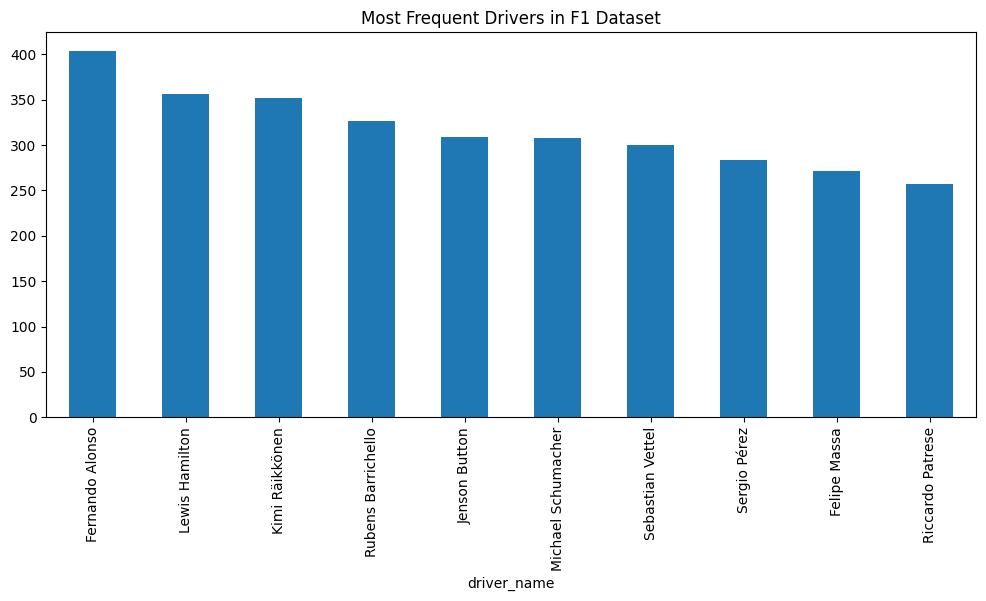

In [35]:
plt.figure(figsize=(12,5))

f1['driver_name'].value_counts().head(10).plot(
    kind='bar'
)

plt.title(
    "Most Frequent Drivers in F1 Dataset"
)

plt.show()

In [36]:
f1 = f1.merge(
    constructors[['constructorId','name']],
    on='constructorId'
)

In [37]:
f1.rename(
    columns={
        'name':'team_name'
    },
    inplace=True
)

In [38]:
f1['team_name'].value_counts().head(10)

team_name
Ferrari       2439
McLaren       1923
Williams      1676
Tyrrell        881
Team Lotus     871
Sauber         837
Red Bull       788
Renault        787
Minardi        672
Brabham        662
Name: count, dtype: int64

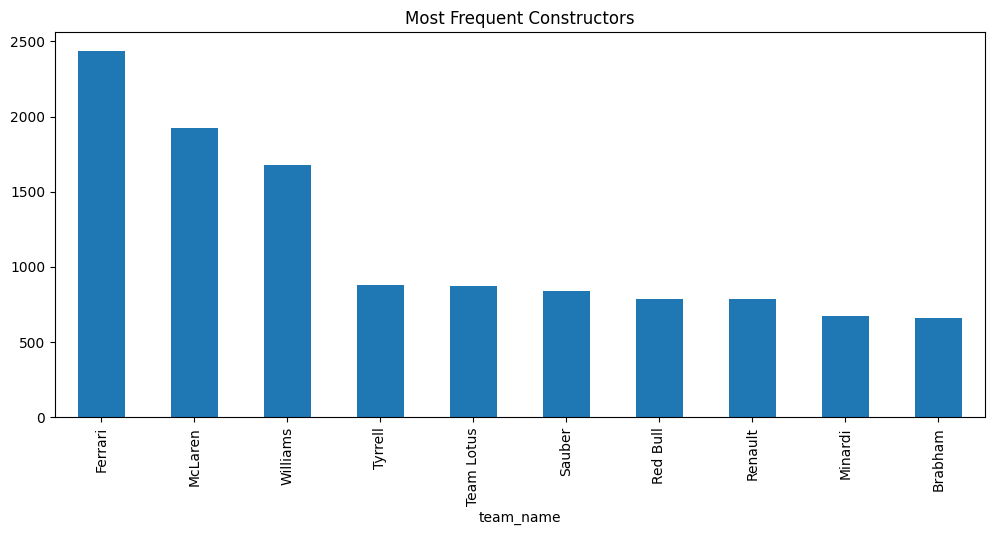

In [39]:
plt.figure(figsize=(12,5))

f1['team_name'].value_counts().head(10).plot(
    kind='bar'
)

plt.title(
    "Most Frequent Constructors"
)

plt.show()

Exploratory Data Analysis

In [40]:
f1 = results.merge(
    drivers[['driverId','forename','surname']],
    on='driverId'
)

f1['driver_name'] = (
    f1['forename']
    + " "
    + f1['surname']
)

In [41]:
driver_points = f1.groupby(
    'driver_name'
)['points'].sum().sort_values(
    ascending=False
).head(10)

driver_points

driver_name
Lewis Hamilton        4820.5
Sebastian Vettel      3098.0
Max Verstappen        2912.5
Fernando Alonso       2329.0
Kimi Räikkönen        1873.0
Valtteri Bottas       1788.0
Nico Rosberg          1594.5
Sergio Pérez          1585.0
Michael Schumacher    1566.0
Charles Leclerc       1363.0
Name: points, dtype: float64

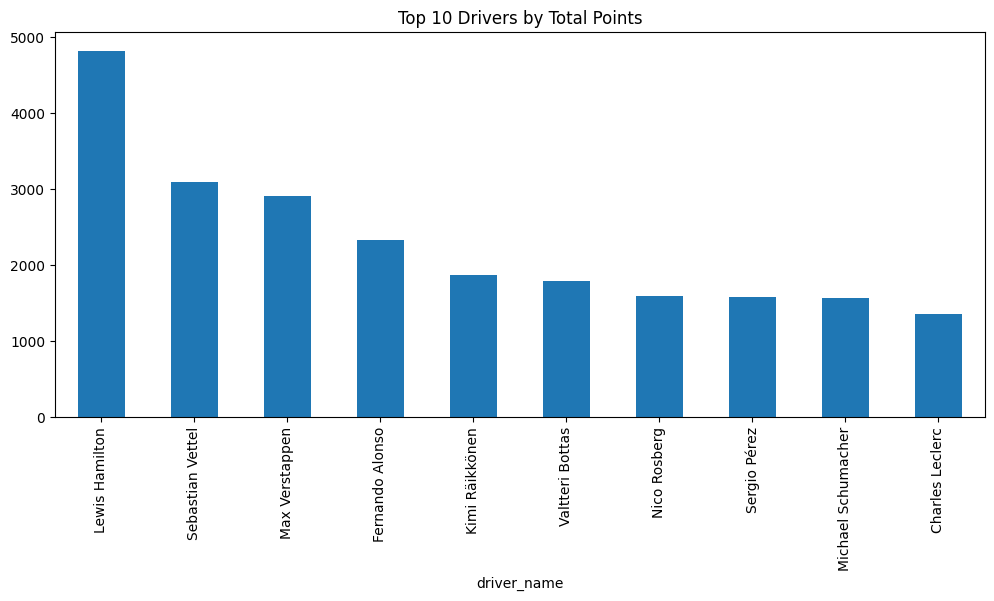

In [42]:
plt.figure(figsize=(12,5))

driver_points.plot(
    kind='bar'
)

plt.title(
    "Top 10 Drivers by Total Points"
)

plt.show()

In [43]:
f1 = f1.merge(
    constructors[['constructorId','name']],
    on='constructorId'
)

f1.rename(
    columns={'name':'team_name'},
    inplace=True
)

In [44]:
team_points = f1.groupby(
    'team_name'
)['points'].sum().sort_values(
    ascending=False
).head(10)

team_points

team_name
Ferrari        11091.27
Mercedes        7730.64
Red Bull        7673.00
McLaren         7022.50
Williams        3641.00
Renault         1777.00
Force India     1098.00
Team Lotus       995.00
Benetton         861.50
Tyrrell          711.00
Name: points, dtype: float64

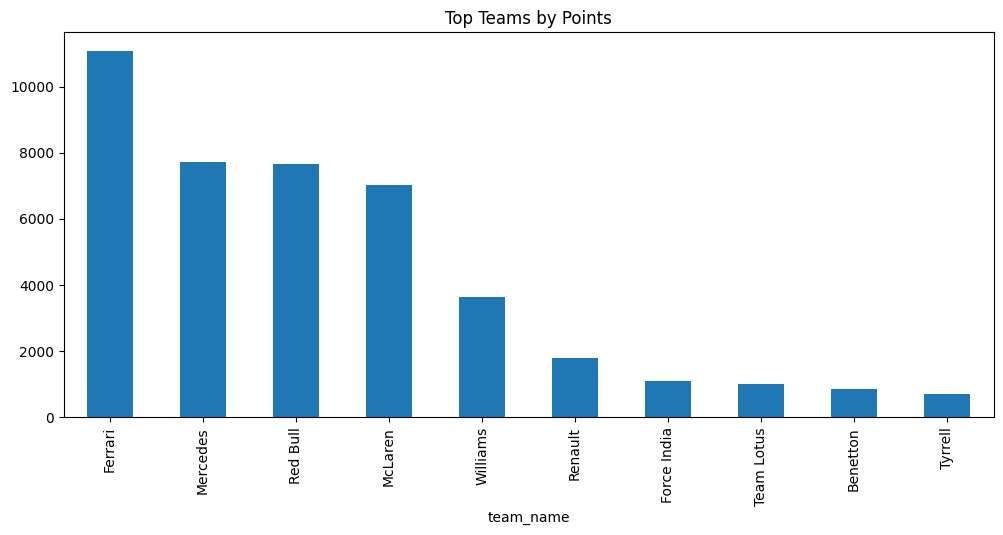

In [45]:
plt.figure(figsize=(12,5))

team_points.plot(
    kind='bar'
)

plt.title(
    "Top Teams by Points"
)

plt.show()

In [46]:
positionOrder = 1

In [47]:
wins = f1[
    f1['positionOrder'] == 1
]

top_winners = wins[
    'driver_name'
].value_counts().head(10)

top_winners

driver_name
Lewis Hamilton        105
Michael Schumacher     91
Max Verstappen         63
Sebastian Vettel       53
Alain Prost            51
Ayrton Senna           41
Fernando Alonso        32
Nigel Mansell          31
Jackie Stewart         27
Niki Lauda             25
Name: count, dtype: int64

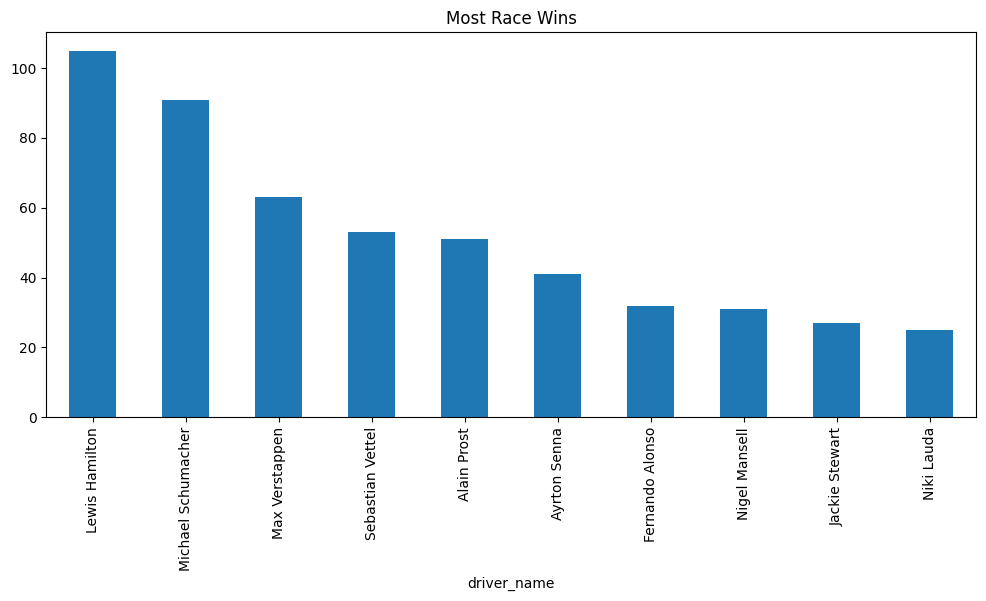

In [48]:
plt.figure(figsize=(12,5))

top_winners.plot(
    kind='bar'
)

plt.title(
    "Most Race Wins"
)

plt.show()